<a href="https://colab.research.google.com/github/sofiasanvi/PRO1/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import csv
import matplotlib.pyplot as plt
import statistics
import numpy as np

{'TARA_N000000077': 717, 'TARA_A100001640': 3380, 'TARA_N000000835': 1529, 'TARA_N000000827': 5196, 'TARA_N000000839': 2345, 'TARA_N000000845': 809, 'TARA_N000000837': 2857, 'TARA_N000000829': 6170, 'TARA_N000000833': 6552, 'TARA_N000000841': 1766, 'TARA_A100000402': 674, 'TARA_A100001646': 1348, 'TARA_A100000394': 1710, 'TARA_A100000393': 4808, 'TARA_A100000400': 1594, 'TARA_E500000200': 1085, 'TARA_A100000398': 1693, 'TARA_A100000396': 6211, 'TARA_E500000196': 2584, 'TARA_N000001664': 1292, 'TARA_N000001654': 2813, 'TARA_N000001646': 4468, 'TARA_N000001650': 4889, 'TARA_N000001658': 3030, 'TARA_N000001656': 2068, 'TARA_N000001648': 3013, 'TARA_N000001652': 3305, 'TARA_N000001660': 1158, 'TARA_A100000546': 724, 'TARA_A100000553': 3014, 'TARA_A100000551': 5712, 'TARA_A100001333': 5277, 'TARA_A100000548': 3202, 'TARA_A100000554': 2088, 'TARA_A100000558': 470, 'TARA_A100000559': 5607, 'TARA_A100000556': 1355, 'TARA_A100000594': 809, 'TARA_A100000598': 2493, 'TARA_A100000595': 4441, 'TARA

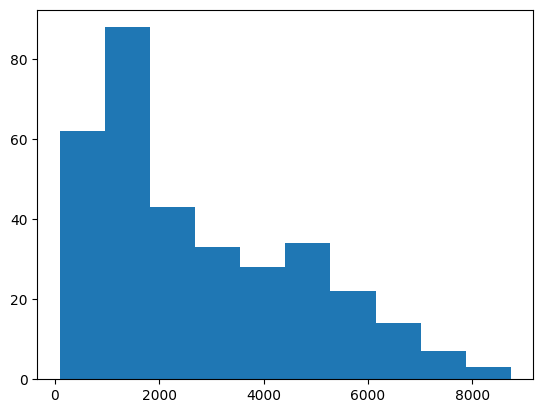

In [3]:
filename = "Database_W5_OTU_occurences.tsv"

with open(filename, "r", encoding="utf-8") as file:
    reader = csv.DictReader(file, delimiter="\t")

    sample_columns = []

    for column in reader.fieldnames:
        if column.startswith("TARA_"):
            sample_columns.append(column)

    richness = {}

    for sample in sample_columns:
        richness[sample] = 0

    for row in reader:
        for sample in sample_columns:
            count = float(row[sample])

            if count > 0:
                richness[sample] += 1

print(richness)
print("Mean richness:", statistics.mean(richness.values()))
print("Variance in richness:", statistics.variance(richness.values()))
plt.hist(richness.values())
plt.show()

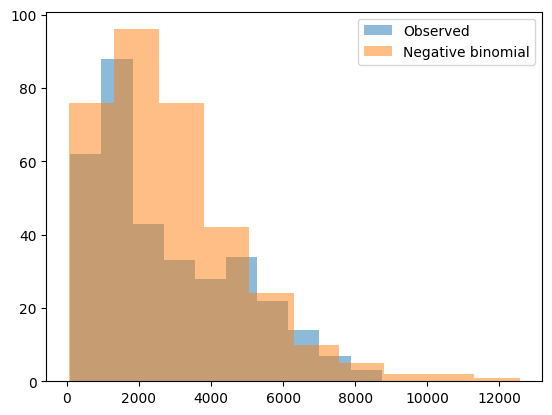

In [4]:
values = np.array(list(richness.values()))

mean = np.mean(values)
variance = np.var(values, ddof=1)

n = mean**2 / (variance - mean)
p = n / (n + mean)

random_nb = np.random.negative_binomial(n, p, size=len(values))

plt.hist(values, alpha=0.5, label="Observed")
plt.hist(random_nb, alpha=0.5, label="Negative binomial")

plt.legend()
plt.show()